In [22]:
import importlib
import auxfun
importlib.reload(auxfun)
from auxfun import *

In [23]:
path = "..\\Envíos\\historico_operativa.xlsx"
fecha_fin = "2026-05-13"
historico_valor_cartera(path, fecha_fin, capital_inicial=10_000_000, hoja="Operativa", incluir_costes=True)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:44: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


,Cash,Valor acciones,Dividendos diarios,Valor cartera,Rentabilidad diaria
Date,,,,,
2026-03-12,0.000000,9.990013e+06,0.000,9.990013e+06,0.000000
2026-03-13,0.000000,9.908388e+06,0.000,9.908388e+06,-0.008171
2026-03-16,0.000000,9.973624e+06,0.000,9.973624e+06,0.006584
2026-03-17,0.000000,1.000886e+07,0.000,1.000886e+07,0.003533
2026-03-18,0.000000,9.867523e+06,0.000,9.867523e+06,-0.014121
2026-03-19,0.000000,9.586114e+06,0.000,9.586114e+06,-0.028519
2026-03-20,-2665.153383,9.447849e+06,0.000,9.445184e+06,-0.014701
2026-03-23,4263.846617,9.521885e+06,6929.000,9.526149e+06,0.008572
2026-03-24,4263.846617,9.492344e+06,0.000,9.496608e+06,-0.003101


In [24]:
universo_tickers = get_eurostoxx50_tickers()
semanal = auxfun.tabla_semanal_atribucion(
    archivo=path,
    universo_tickers=universo_tickers,
    fecha_fin=fecha_fin,
    capital_inicial=10_000_000
)

detalle_acumulado, final = auxfun.encadenar_atribucion(semanal)
semanal_fmt, final_fmt = auxfun.formatear_atribucion(semanal, final)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:44: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


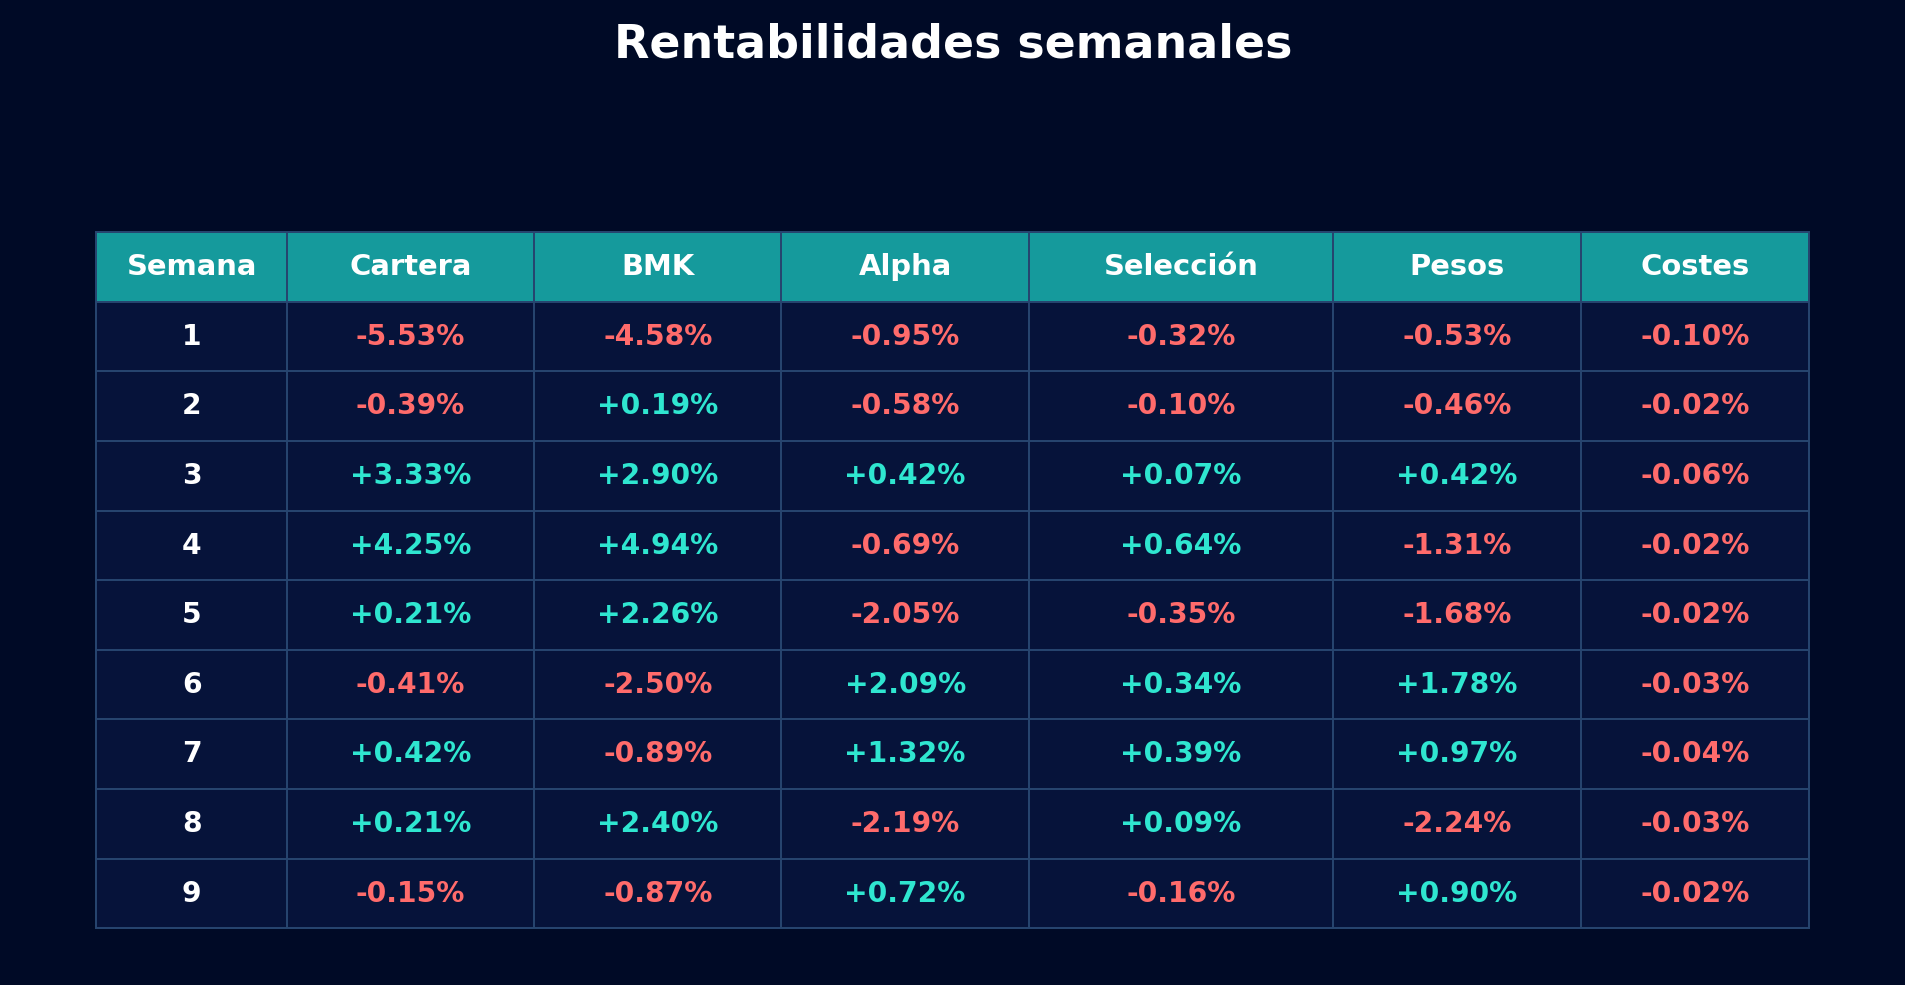

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def tabla_semanal_canva(semanal, ultimas=10, guardar="detalle_semanal_canva.png"):
    cols = {
        "Rent. cartera neta": "Cartera",
        "Rent. BMK": "BMK",
        "Alpha": "Alpha",
        "Ef. selección": "Selección",
        "Ef. pesos": "Pesos",
        "Costes": "Costes",
    }

    df = semanal[list(cols)].rename(columns=cols).tail(ultimas).copy()
    df.insert(0, "Semana", [str(i + 1) for i in range(len(df))])

    for c in df.columns[1:]:
        df[c] = df[c].map(lambda x: f"{x*100:+.2f}%")

    fondo = "#000A26"
    panel = "#06133A"
    header = "#159A9C"
    lineas = "#27456F"
    blanco = "#FFFFFF"
    positivo = "#2FE6D0"
    negativo = "#FF6B6B"

    fig, ax = plt.subplots(figsize=(8.6, 4.4), dpi=220)
    fig.patch.set_facecolor(fondo)
    ax.set_facecolor(fondo)
    ax.axis("off")

    tabla = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.04, 0.04, 0.92, 0.80]  # izquierda, abajo, ancho, alto
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9.2)
    tabla.scale(0.88, 1.45)

    anchos = {
        0: 0.10,  # Semana
        1: 0.13,  # Cartera
        2: 0.13,  # BMK
        3: 0.13,  # Alpha
        4: 0.16,  # Selección
        5: 0.13,  # Pesos
        6: 0.12,  # Costes
    }

    for (fila, col), celda in tabla.get_celld().items():
        celda.set_edgecolor(lineas)
        celda.set_linewidth(0.65)
        celda.set_width(anchos.get(col, 0.13))

        if fila == 0:
            celda.set_facecolor(header)
            celda.get_text().set_color(blanco)
            celda.get_text().set_weight("bold")
            celda.get_text().set_fontsize(9.5)
        else:
            celda.set_facecolor(panel)
            celda.get_text().set_weight("bold")   # números en negrita
            celda.get_text().set_fontsize(9.2)

            if col == 0:
                celda.get_text().set_color(blanco)
            else:
                valor = str(df.iloc[fila - 1, col])
                if valor.startswith("+"):
                    celda.get_text().set_color(positivo)
                elif valor.startswith("-"):
                    celda.get_text().set_color(negativo)
                else:
                    celda.get_text().set_color(blanco)

    ax.text(
        0.5, 1.03,
        "Rentabilidades semanales",
        ha="center", va="bottom",
        color=blanco,
        fontsize=15,
        fontweight="bold",
        transform=ax.transAxes
    )

    plt.tight_layout(pad=0.5)

    if guardar:
        fig.savefig(guardar, dpi=300, bbox_inches="tight", facecolor=fondo)

    plt.show()
    return fig, ax

fig, ax = tabla_semanal_canva(
    semanal,
    ultimas=10,
    guardar="detalle_semanal_canva.png"
)

In [26]:

display(semanal_fmt)
display(final_fmt)

,NAV inicial,NAV final,Rent. cartera neta,Alpha,Ef. selección,Ef. pesos,Costes
Periodo,,,,,,,
2026-03-12 → 2026-03-20,"10,000.0 k€","9,447.2 k€",-5.53%,-0.95%,-0.32%,-0.53%,-0.10%
2026-03-20 → 2026-03-27,"9,447.2 k€","9,410.7 k€",-0.39%,-0.58%,-0.10%,-0.46%,-0.02%
2026-03-27 → 2026-04-07,"9,410.7 k€","9,723.8 k€",3.33%,0.42%,0.07%,0.42%,-0.06%
2026-04-07 → 2026-04-10,"9,723.8 k€","10,137.2 k€",4.25%,-0.69%,0.64%,-1.31%,-0.02%
2026-04-10 → 2026-04-17,"10,137.2 k€","10,159.0 k€",0.21%,-2.05%,-0.35%,-1.68%,-0.02%
2026-04-17 → 2026-04-24,"10,159.0 k€","10,116.9 k€",-0.41%,2.09%,0.34%,1.78%,-0.03%
2026-04-24 → 2026-05-04,"10,116.9 k€","10,159.8 k€",0.42%,1.32%,0.39%,0.97%,-0.04%
2026-05-04 → 2026-05-08,"10,159.8 k€","10,181.5 k€",0.21%,-2.19%,0.09%,-2.24%,-0.03%
2026-05-08 → 2026-05-13,"10,181.5 k€","10,166.3 k€",-0.15%,0.72%,-0.16%,0.90%,-0.02%


,Cartera,BMK
NAV final,"10,166.3 k€","10,355.7 k€"
Resultado,166.3 k€ (1.66%),355.7 k€ (3.56%)
Rentabilidad,1.66%,3.56%
Volatilidad anualizada,19.73%,21.46%
Sharpe,0.57,1.04
Alpha vs BMK,-189.4 k€ (-1.89%),
Ef. selección,57.1 k€ (0.57%),
Ef. pesos,-211.2 k€ (-2.11%),
Costes,-35.3 k€ (-0.35%),


c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:44: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()
c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:44: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()
c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\

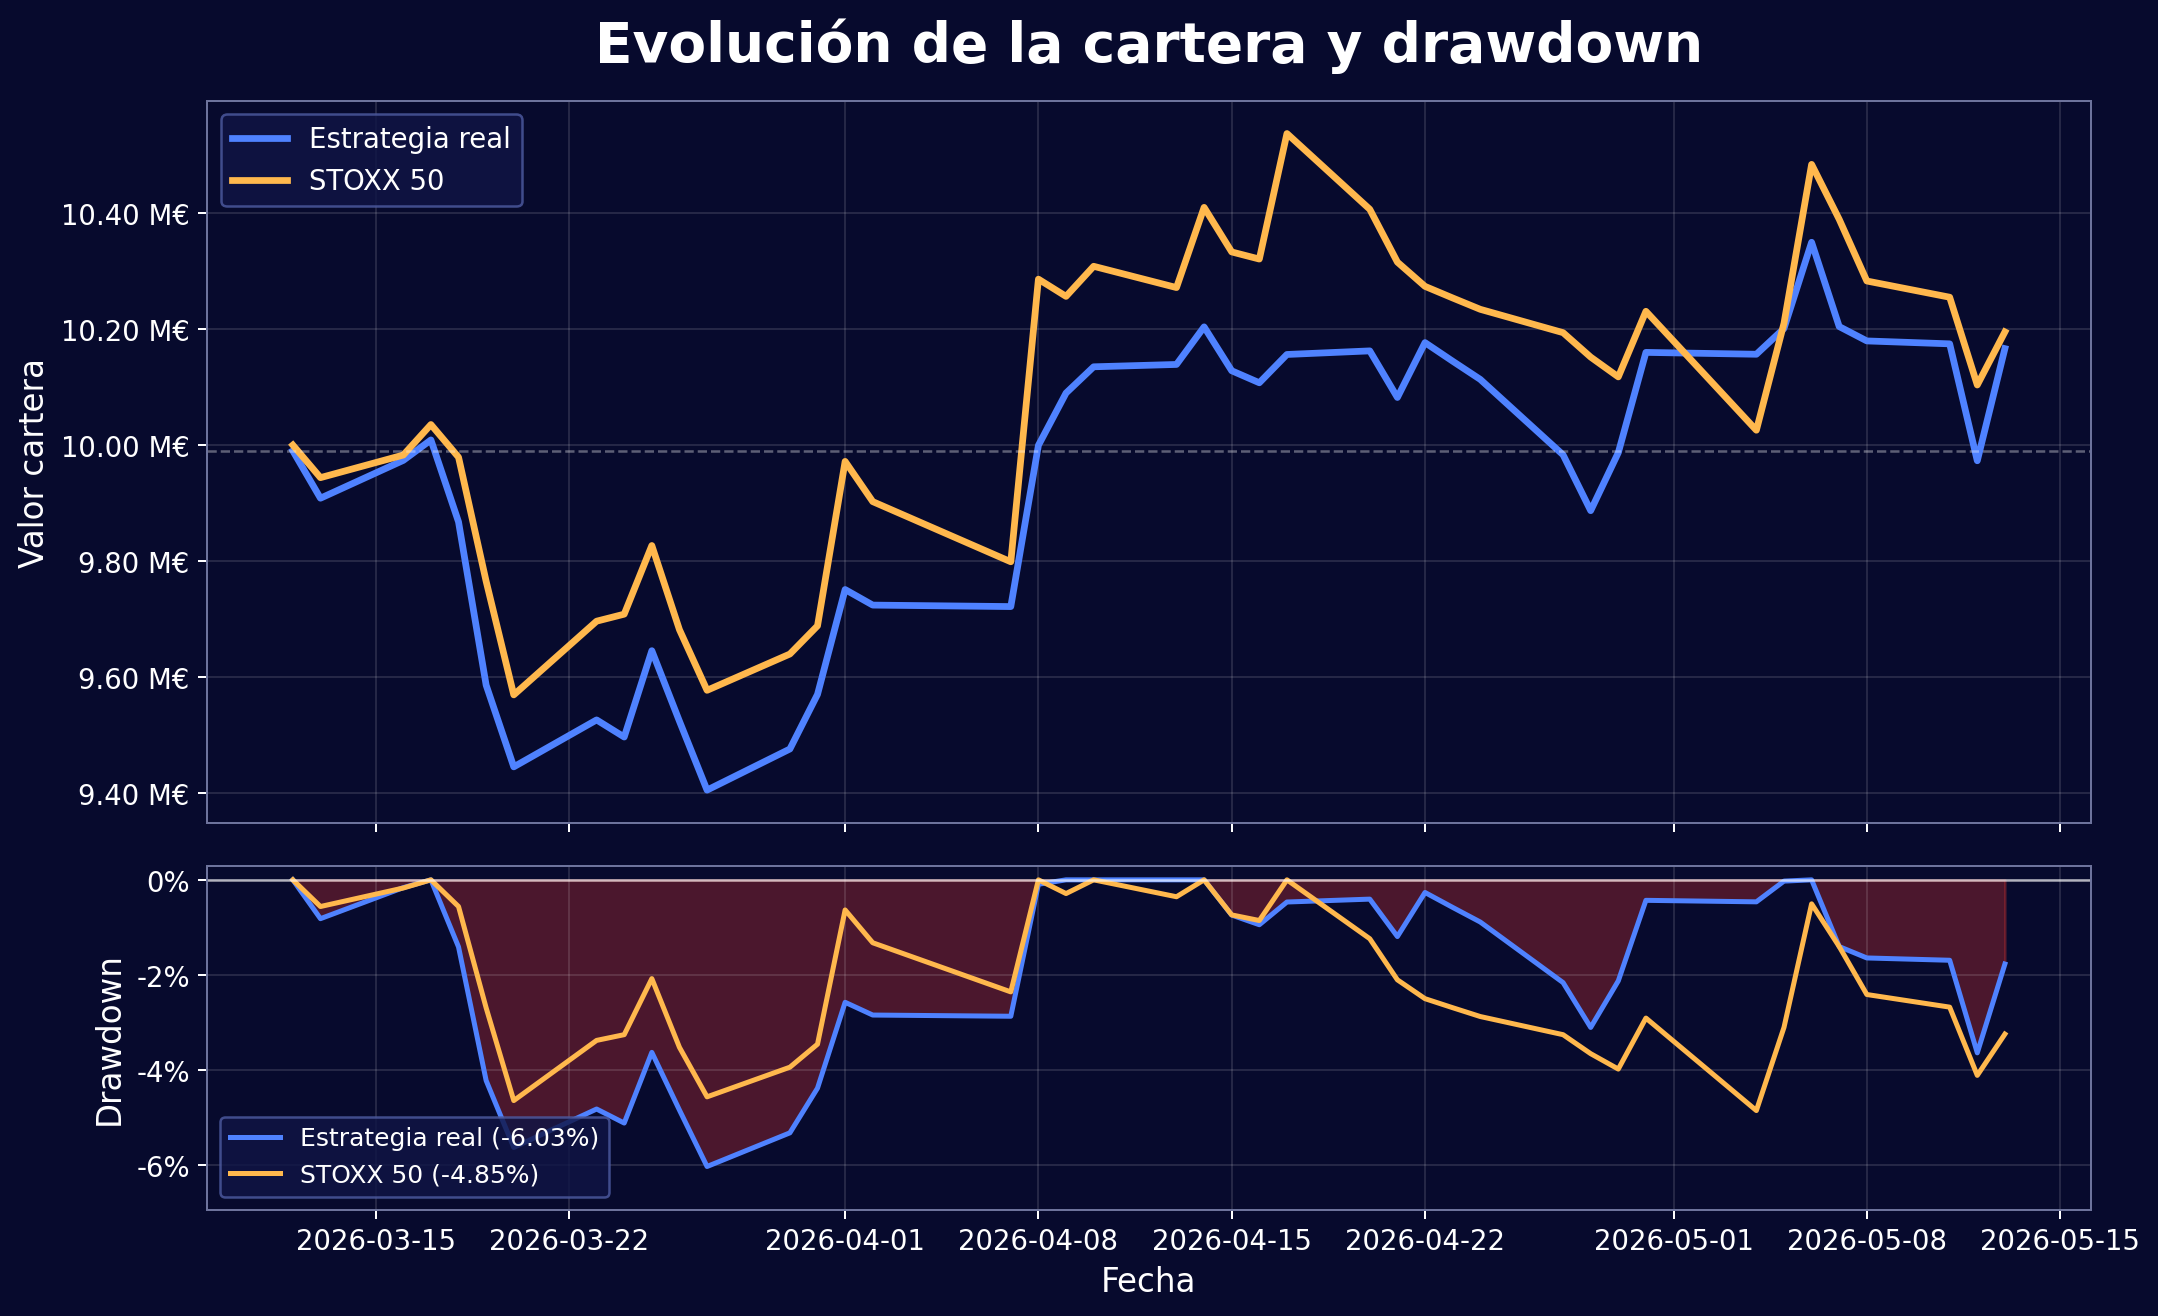

In [ ]:
series_grafico, semanal, final, tabla_metricas, tabla_metricas_fmt = series_diarias_cartera_bmks(
    archivo=path,
    universo_tickers=universo_tickers,
    fecha_fin=fecha_fin,
    capital_inicial=10_000_000,
    benchmark="^STOXX50E"
)

fig, axes = auxfun.grafico_evolucion_drawdown(
    series_grafico,
    titulo="Evolución de la cartera y drawdown"
)

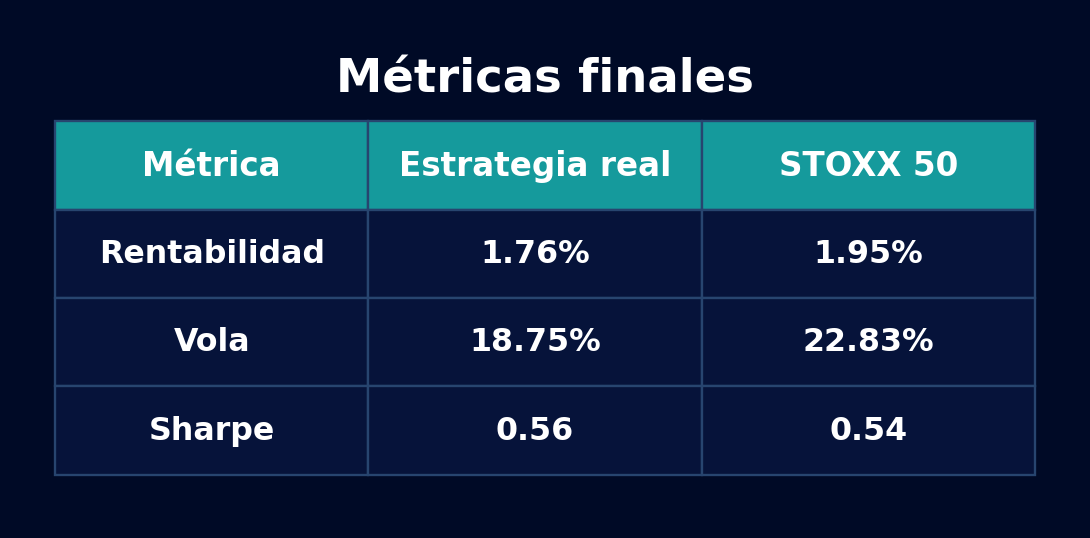

In [36]:
import matplotlib.pyplot as plt

def tabla_metricas_resultados_canva_transpuesta(tabla_metricas, guardar=None):
    df = (
        tabla_metricas
        .set_index("Estrategia")[["Rentabilidad", "Volatilidad", "Sharpe"]]
        .T
        .rename(index={"Volatilidad": "Vola"})
        .astype(object)
    )

    for fila in ["Rentabilidad", "Vola"]:
        df.loc[fila] = df.loc[fila].map(lambda x: f"{float(x):.2%}")

    df.loc["Sharpe"] = df.loc["Sharpe"].map(lambda x: f"{float(x):.2f}")

    df = df.reset_index().rename(columns={"index": "Métrica"})

    fondo = "#000A26"
    panel = "#06133A"
    header = "#159A9C"
    lineas = "#27456F"
    blanco = "#FFFFFF"

    fig, ax = plt.subplots(figsize=(4.4, 2.1), dpi=240)
    fig.patch.set_facecolor(fondo)
    ax.set_facecolor(fondo)
    ax.axis("off")

    tabla = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.03, 0.08, 0.94, 0.72]
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9.6)
    tabla.scale(0.92, 1.45)

    anchos = {0: 0.30, 1: 0.32, 2: 0.32}

    for (fila, col), celda in tabla.get_celld().items():
        celda.set_edgecolor(lineas)
        celda.set_linewidth(0.7)
        celda.set_width(anchos.get(col, 0.3))

        if fila == 0:
            celda.set_facecolor(header)
            celda.get_text().set_color(blanco)
            celda.get_text().set_weight("bold")
            celda.get_text().set_fontsize(9.8)
        else:
            celda.set_facecolor(panel)
            celda.get_text().set_color(blanco)
            celda.get_text().set_weight("bold")
            celda.get_text().set_fontsize(9.5)

    ax.text(
        0.5, 0.84,
        "Métricas finales",
        ha="center", va="bottom",
        color=blanco,
        fontsize=14,
        fontweight="bold",
        transform=ax.transAxes
    )

    plt.tight_layout(pad=0.2)

    if guardar:
        fig.savefig(guardar, dpi=300, bbox_inches="tight", facecolor=fondo)

    plt.show()
    return fig, ax

fig, ax = tabla_metricas_resultados_canva_transpuesta(tabla_metricas, guardar=None)

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:44: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


P&L medio por activo: 6,396.96 €


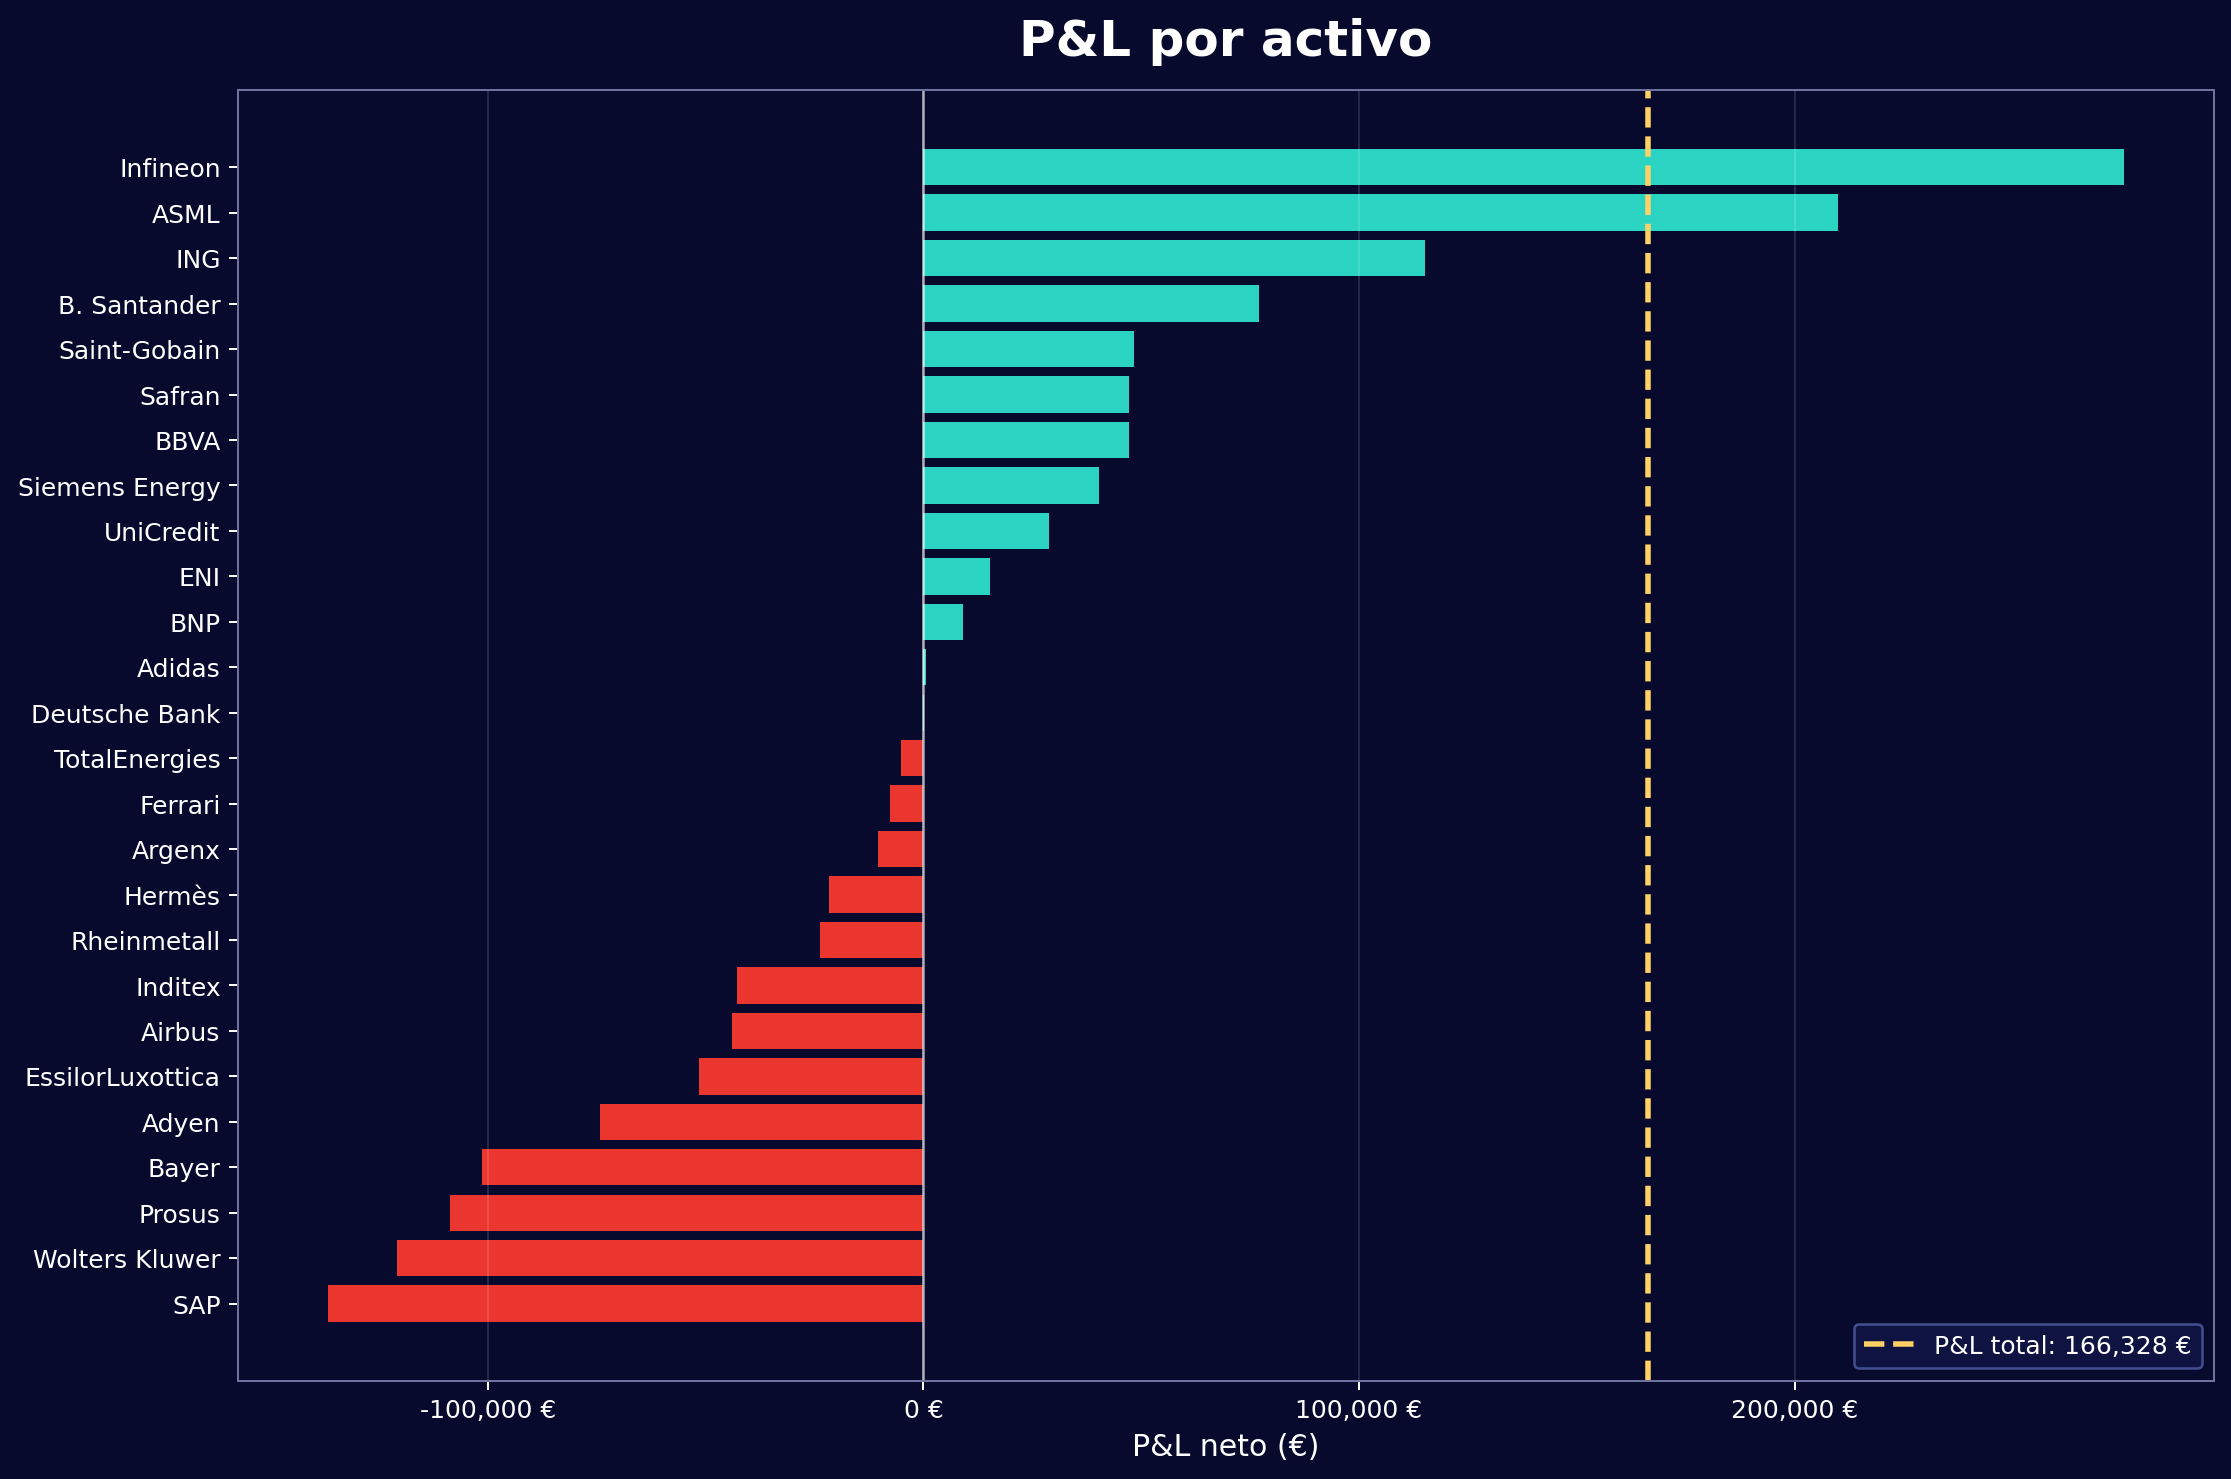

In [28]:
pnl_activos, fig, ax = auxfun.pnl_por_activo(
    archivo=path,
    fecha_fin=fecha_fin,
    capital_inicial=10_000_000
)

# display(pnl_activos.style.format({"P&L (€)": "{:,.0f} €"}))

In [10]:
fig = auxfun.grafico_evolucion_drawdown_plotly(series_grafico, titulo="")
fig.write_image("silva_alpha_nav_dd.svg", engine="kaleido")

C:\Users\juanc\AppData\Local\Temp\ipykernel_16592\1319551068.py:2: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image("silva_alpha_nav_dd.svg", engine="kaleido")
